# DSA5102 Final Group Project
## Training the machine to play Snake using DNN

- **Lecture**：DSA5102 - Foundations of Machine Learning
- **Topic**：Option 2 —— Train the machine to play a classic game using Reinforcement Learning
- **Group**：`Group7: ZHANG FANFEIYANG, CHE JUNYI, HAN YUTONG, LIU YUYAN, WANG HONGLIN`
- **DATE**：2026-11

> **Note**: This notebook is the final submission (project report). The `TRAIN_MODEL = False` switch at the top
> loads pre-trained models by default, so the notebook runs without re-training. Each section header marks its owner.

## 0. Project Overview and Declaration

### 0.1 Topic and Goal

We choose **Option 2 (Reinforcement Learning)** to train an agent to play the classic game **Snake**.
We implement three learning algorithms (Actor-Critic, DQN, PPO) plus the improved DQN variant Double DQN,
compare their performance under shared random seeds and independent evaluation environments,
and use a random policy and a rule-based teacher policy as baselines.

### 0.2 Code Provenance

The implementations follow standard reinforcement-learning formulations (DQN, Actor-Critic, PPO)
and the Gymnasium interface. Some code structure is informed by publicly available RL tutorials;
the specific design choices and experiments are described within each section.

### 0.3 Generative AI Usage Declaration

> **【To be filled after confirmation by all members】** Declare honestly whether, which tool, and for what purpose
> generative AI was used (e.g., code comments, figure layout, section polishing, debugging). If not used, explicitly
> write "generative AI was not used". A false declaration will result in a zero for both parts if discovered.

### 0.4 Global Setup

- `TRAIN_MODEL`: keep `False` for the final submission (load pre-trained models); set `True` to re-train.
- Keep the notebook in the same directory as `environment.py` / `model.py` / `dqn.py` / `ppo.py` so they can be imported directly.

In [5]:
# ==================== Global setup ====================
# Keep False for the final submission (load pre-trained models); set True to re-train
TRAIN_MODEL = False

import sys
from pathlib import Path

# The notebook can import the modules directly if it sits next to the .py source files;
# otherwise add the source directory to the path.
HERE = Path.cwd()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import numpy as np
import torch
import matplotlib.pyplot as plt

from environment import SnakeEnv
from model import ConvActorCritic
from dqn import DQNAgent, ReplayBuffer
from ppo import PPOAgent
from main import choose_device   # auto-select cpu/mps/cuda

# Check whether pre-trained models exist
RUNS = Path("runs")
print("cwd:", HERE)
print("runs directory exists:", RUNS.exists())
if RUNS.exists():
    for p in sorted(RUNS.rglob("*.pt"))[:10]:
        print("  checkpoint:", p)

cwd: /Users/zhangfanfeiyang/Desktop/期末项目/贪吃蛇
runs 目录存在: False


---
# 1. Game Introduction and Environment Modeling  【Member 1】

## 1.1 Snake rules (assume the reader has never played it)

> **【Member 1 to fill in】** Explain the rules in one or two paragraphs: the board, the snake, the food, movement,
> growing when eating, dying on wall/self collision, and the goal. The code below draws a board diagram.

## 1.2 Visualizing the board

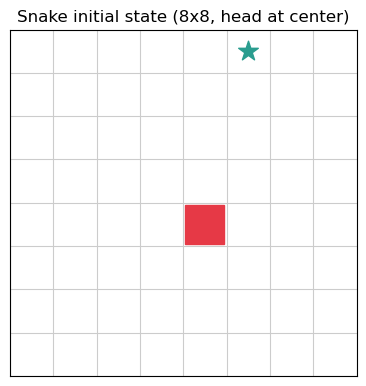

In [8]:
# Draw the snake board using the real environment's initial state (head at center, random food)
env_demo = SnakeEnv(grid_size=8, end_score=8, max_steps=300)
obs, _ = env_demo.reset(seed=42)
snake_mask = obs[0]   # channel 0: snake body
food_mask = obs[1]    # channel 1: food

GRID = 8
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.set_xlim(0, GRID); ax.set_ylim(GRID, 0); ax.set_aspect("equal")
for i in range(GRID + 1):
    ax.axhline(i, color="#cccccc", lw=0.8)
    ax.axvline(i, color="#cccccc", lw=0.8)

# snake body (initially only the head)
for r in range(GRID):
    for c in range(GRID):
        if snake_mask[r, c]:
            ax.add_patch(plt.Rectangle((c + 0.05, r + 0.05), 0.9, 0.9, color="#e63946"))
# food
for r in range(GRID):
    for c in range(GRID):
        if food_mask[r, c]:
            ax.scatter(c + 0.5, r + 0.5, s=220, marker="*", color="#2a9d8f")

ax.set_xticks([]); ax.set_yticks([]); ax.set_title("Snake initial state (8x8, head at center)")
plt.show()
env_demo.close()

共 39 帧，最终 score=7, steps=38
已保存 snake_game.gif


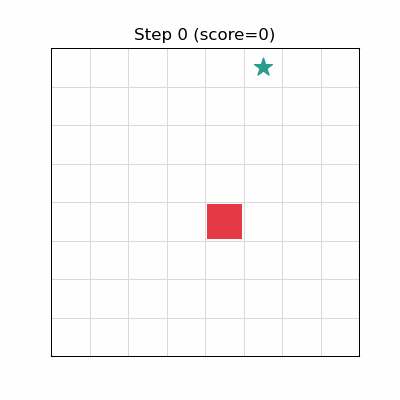

In [10]:
# Visualize a full game played by the teacher policy, and export / display the GIF
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import Image, display

# 1) Play a full game with the teacher policy, recording the snake and food at every frame
env = SnakeEnv(grid_size=8, end_score=8, max_steps=300)
obs, _ = env.reset(seed=42)
snake_frames = [env.snake.copy()]
food_frames = [env.food_pos.copy()]
while True:
    obs, reward, terminated, truncated, info = env.step(env.teacher_action())
    snake_frames.append(env.snake.copy())
    food_frames.append(env.food_pos.copy())
    if terminated or truncated:
        break
env.close()
print(f"Total {len(snake_frames)} frames, final score={info['score']}, steps={info['steps']}")

# 2) Draw the board frame by frame and export a GIF
GRID = 8
fig, ax = plt.subplots(figsize=(4, 4))

def draw_frame(i):
    ax.clear()
    ax.set_xlim(0, GRID); ax.set_ylim(GRID, 0); ax.set_aspect("equal")
    for g in range(GRID + 1):
        ax.axhline(g, color="#cccccc", lw=0.5)
        ax.axvline(g, color="#cccccc", lw=0.5)
    for idx, seg in enumerate(snake_frames[i]):
        r, c = int(seg[0]), int(seg[1])
        color = "#e63946" if idx == 0 else "#f4a261"
        ax.add_patch(Rectangle((c + 0.05, r + 0.05), 0.9, 0.9, facecolor=color, edgecolor="none"))
    food = food_frames[i]
    ax.scatter(int(food[1]) + 0.5, int(food[0]) + 0.5, s=180, marker="*", color="#2a9d8f", zorder=3)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"Step {i} (score={len(snake_frames[i]) - 1})")

anim = animation.FuncAnimation(fig, draw_frame, frames=len(snake_frames), interval=200)
anim.save("snake_game.gif", writer="pillow", fps=5)
plt.close(fig)
print("Saved snake_game.gif")
display(Image(filename="snake_game.gif"))

## 1.3 Modeling state, action and reward

> **【Member 1 to fill in】** Explain the three core design decisions (also the focus of the presentation):
> 1. **Action space**: why three relative actions (left/right/straight) instead of four absolute ones (up/down/left/right).
> 2. **Observation space**: the 7-channel grid — what each channel encodes (snake, food, wall, four directions).
> 3. **Reward function** (two switchable modes, controlled by `reward_mode`). Common part: eat food +10, win +100,
>    wall/self collision −5, per-step survival −0.01.
>    - `"sparse"` (default): sparse event rewards, with an extra −0.5 penalty for looping (no shaping);
>    - `"dense"`: additionally distance shaping (closer +0.2 / farther −0.1), new-cell exploration +0.2, looping −0.4.
> The code below initializes the environment and visualizes the observation.

Action space: Discrete(3)
Observation space: Box(0.0, 1.0, (7, 8, 8), float32)
obs shape: (7, 8, 8) dtype: float32
reset info: {'score': 0, 'length': 1, 'steps': 0, 'executed_action': None}


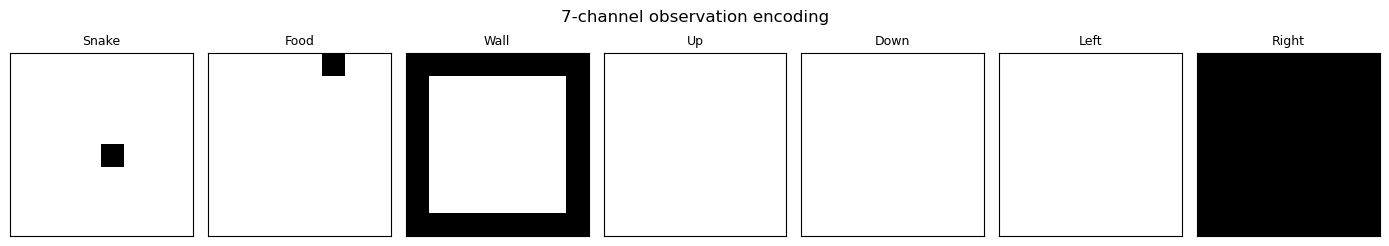

In [13]:
# Initialize the environment and inspect action / observation spaces
env = SnakeEnv(grid_size=8, end_score=8, max_steps=300)
print("Action space:", env.action_space)          # Discrete(3): 0=left, 1=right, 2=straight
print("Observation space:", env.observation_space)  # Box(7, 8, 8): 7 channels, 8x8 grid

obs, info = env.reset(seed=42)
print("obs shape:", obs.shape, "dtype:", obs.dtype)
print("reset info:", info)

# Visualize the 7 observation channels (snake / food / wall / direction)
fig, axes = plt.subplots(1, 7, figsize=(14, 2.5))
channel_names = ["Snake", "Food", "Wall", "Up", "Down", "Left", "Right"]
for i, ax in enumerate(axes):
    ax.imshow(obs[i], cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(channel_names[i], fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("7-channel observation encoding")
plt.tight_layout()
plt.show()
env.close()

## 1.4 The rule-based teacher policy (one of the baselines; Member 1 presents)

> **【Member 1 to fill in and present】** Explain the idea behind `teacher_action()` (two variants, controlled by `teacher_mode`):
> - `"shortest_path"` (default): for each action, step once and use BFS to compute the true shortest path to the food
>   (treating the snake body as obstacles), then pick the action with the fewest steps; if the food is unreachable,
>   fall back to the action that maximizes reachable free space to survive longer.
> - `"legacy"`: Manhattan-distance greedy — pick the safe action closest to the food.
> This is the heuristic-rule baseline, and also the source of demonstrations for behavior cloning (Member 2).
> **Cross reference**: behavior cloning is in §2 (Member 2); evaluation as a baseline is in §5 (Member 5).

In [16]:
# Demonstrate the teacher policy: first see how it decides in the initial state, then play a full game
env = SnakeEnv(grid_size=8, end_score=8, max_steps=300)
obs, _ = env.reset(seed=42)

# Take one step to see the teacher's decision
action = env.teacher_action()
print("Initial teacher action:", action, "(0=left, 1=right, 2=straight)")
obs, reward, terminated, truncated, info = env.step(action)
print("After step: reward=%.2f | score=%s | length=%s" % (reward, info["score"], info["length"]))

# Play a full game: the teacher plays until the end
total_reward = reward
while not (terminated or truncated):
    action = env.teacher_action()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
print("Teacher full game: score=%s | steps=%s | total reward=%.2f" % (info["score"], info["steps"], total_reward))
env.close()

初始状态教师动作: 0 (0=左转, 1=右转, 2=直行)
执行后: 奖励=-0.01 | score=0 | length=1
教师策略一局: score=7 | steps=38 | 累计奖励=169.69


In [18]:
# Baseline evaluation: random policy vs rule-based teacher (main 8x8 setting, 100 games each)
def evaluate_baseline(policy, n_episodes=100, seed=0):
    env = SnakeEnv(grid_size=8, end_score=8, max_steps=300)
    scores = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        while True:
            action = env.action_space.sample() if policy == "random" else env.teacher_action()
            obs, reward, terminated, truncated, info = env.step(action)
            if terminated or truncated:
                scores.append(info["score"])
                break
    env.close()
    return float(np.mean(scores))

print("random baseline mean score:", evaluate_baseline("random"))
print("teacher baseline mean score:", evaluate_baseline("teacher"))

# Comparison experiment: on a dense 10x10 board with a long snake,
# compare the Manhattan-greedy teacher vs the BFS shortest-path teacher.
# Note: on the 8x8 main setting both are near-perfect and barely differ, so we use an
# extreme setting to amplify the difference.
def evaluate_teacher(mode, n_episodes=200, seed=0, grid_size=10, end_score=20, max_steps=500):
    env = SnakeEnv(grid_size=grid_size, end_score=end_score, max_steps=max_steps, teacher_mode=mode)
    scores = []; deaths = 0
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        while True:
            obs, reward, terminated, truncated, info = env.step(env.teacher_action())
            if terminated or truncated:
                scores.append(info["score"])
                if terminated and info["length"] < end_score:  # died: terminated but did not win
                    deaths += 1
                break
    env.close()
    return float(np.mean(scores)), deaths / n_episodes

legacy_score, legacy_death = evaluate_teacher("legacy")
sp_score, sp_death = evaluate_teacher("shortest_path")
print(f"legacy (Manhattan greedy) mean={legacy_score:.2f}  death rate={legacy_death:.0%}")
print(f"shortest_path (BFS)    mean={sp_score:.2f}  death rate={sp_death:.0%}")

random 基线平均分: 0.08
teacher 基线平均分: 7.0
legacy（曼哈顿贪心）  平均分=16.95  撞死率=46%
shortest_path（BFS） 平均分=18.81  撞死率=7%


---
# 2. 方法一：Actor-Critic 与行为克隆　【成员 2 负责】

## 2.1 方法原理

> **【成员 2 填写】** 讲清楚：
> 1. **行为克隆预热**：前 `teacher_episodes` 轮用规则教师（§1.4）的示范做监督学习（交叉熵），解决冷启动。
> 2. **Actor-Critic 更新**：`advantage = target − V(s)`，policy gradient 项 + critic 的 value loss + 熵正则。
> 3. 损失函数拆解（参考 `model.py` 的 `update()`）。

## 2.2 构建模型


In [ ]:
# 构建 Actor-Critic 模型（成员 2）
env = SnakeEnv(grid_size=8, end_score=8, max_steps=300)
agent_ac = ConvActorCritic(
    input_channels=env.observation_space.shape[0],
    output_dim=env.action_space.n,
    grid_size=8,
    lr=1e-4,
    weight_decay=1e-5,
    entropy_coef=0.01,
)
print(agent_ac)
env.close()

## 2.3 训练（或加载模型）

> 训练入口在 `main.py` 的 `train()`。默认 `TRAIN_MODEL=False` 时加载 checkpoint。
> **成员 2 的实质改动**：新增「有/无行为克隆预热」对照，把 `teacher_episodes` 设为 0 跑一版做对比。


In [ ]:
if TRAIN_MODEL:
    from main import TrainConfig, train
    summary_ac = train(TrainConfig(
        episodes=500,
        teacher_episodes=100,   # 成员 2 改动点：对比 0 vs 100 的预热效果
        grid_size=8,
        end_score=8,
        max_steps=300,
        seed=42,
        device="auto",
        output_dir=Path("runs/snake"),
        tensorboard=False,
    ))
    print(summary_ac)
else:
    # 加载已训练好的模型
    ckpt = Path("runs/snake/checkpoints/best.pt")
    print("加载 AC checkpoint:", ckpt, "存在:", ckpt.exists())
    # agent_ac.load_checkpoint(ckpt)  # 取消注释以加载权重

## 2.4 学习曲线

> **【成员 2 填写】** 训练过程会写 TensorBoard 事件；这里从训练返回或 `history` 里取 reward/score 画学习曲线。
> 若用 `TRAIN_MODEL=False`，请把训练时保存的曲线数据（`summary.json` / TensorBoard）读进来画图。


In [ ]:
# AC 学习曲线（成员 2：填入实际训练曲线数据）
# 示例占位：横轴 episode，纵轴 episode reward
# plt.plot(episodes, rewards); plt.xlabel("Episode"); plt.ylabel("Reward"); plt.title("AC 学习曲线")
print("TODO: 绘制 AC 学习曲线（reward / score vs episode）")


## 2.5 训练进度可视化（成员 2）

> **【成员 2 填写 + 必做】** 这是 Option 2 的明确得分点：**视觉展示玩法随训练进步**。
> 用 `save_interval` 保存的不同阶段 checkpoint（或用成员 4 提供的通用脚本），
> 渲染「早期（乱撞）vs 后期（稳定吃分）」的对比图 / GIF，并写一段文字说明观察到的进步。


In [ ]:
# AC 训练进度可视化（成员 2：加载早期/后期 checkpoint 分别渲染并排对比）
print("TODO: 渲染 AC 训练早期 vs 后期的对局对比（并排图或 GIF）")


---
# 3. 方法二：DQN 与 Double DQN　【成员 3 负责】

## 3.1 方法原理

> **【成员 3 填写】** 讲清楚：
> 1. **DQN**：经验回放（`ReplayBuffer`）、目标网络、ε-greedy 衰减。
> 2. **Q 值高估问题**：为什么 max 操作会系统性高估。
> 3. **Double DQN**：用在线网络选动作、目标网络估值，如何缓解高估（参考 `dqn.py` 的 `bootstrap_values`）。
> 本成员不涉及 baseline；专注价值方法本身的改进。

## 3.2 构建模型


In [ ]:
# 构建 DQN Agent（成员 3）
env = SnakeEnv(grid_size=8, end_score=8, max_steps=300)
agent_dqn = DQNAgent(
    input_channels=env.observation_space.shape[0],
    action_count=env.action_space.n,
    grid_size=8,
    learning_rate=3e-4,
    device=choose_device("auto"),
)
print("online 网络参数:", agent_dqn.online)
env.close()

## 3.3 训练（或加载模型）

> 训练入口在 `train_dqn.py` 的 `train_dqn()`；Double DQN 通过 `double_dqn=True` 开关。
> **成员 3 的实质改动**：将经验回放改为优先级经验回放（PER），或改 ε 衰减方式，做对照。


In [ ]:
if TRAIN_MODEL:
    from train_dqn import DQNTrainConfig, train_dqn
    for double_dqn, name in [(False, "dqn"), (True, "double_dqn")]:
        summary = train_dqn(DQNTrainConfig(
            episodes=1000,
            grid_size=8, end_score=8, max_steps=300,
            double_dqn=double_dqn,
            seed=42, device="auto",
            output_dir=Path("runs") / name,
            tensorboard=False,
        ))
        print(name, summary)
else:
    for name in ("dqn", "double_dqn"):
        ckpt = Path("runs") / name / "checkpoints" / "best.pt"
        print("加载", name, "checkpoint:", ckpt, "存在:", ckpt.exists())

## 3.4 DQN vs Double DQN 对比（含 Q 值诊断）

> **【成员 3 填写 + 主讲】** 用 `benchmark_double_dqn.py` 的结果画对比图，重点展示：
> 初始 Q 均值、实际折扣回报、Q–回报 gap、Q 高估率、目标选择差值、动作分歧率。
> 用这些诊断量证明「Double 缓解了高估」，再落到最终 reward/score/success 的对比。


In [ ]:
# DQN vs Double DQN 对比（成员 3：读 benchmark_double_dqn.py 导出的 results.csv/json 画图）
import pandas as pd
# df = pd.read_csv("runs/double-dqn-benchmark/results.csv")
# 画 Q 高估率、Q-回报 gap、reward/success 的柱状对比（含误差棒）
print("TODO: 绘制 DQN vs Double DQN 的 Q 值诊断与性能对比图")


## 3.5 训练进度可视化（成员 3）

> **【成员 3 填写 + 必做】** 同 §2.5，渲染 DQN（或 Double DQN）训练早期 vs 后期的对局对比。


In [ ]:
print("TODO: 渲染 DQN 训练早期 vs 后期的对局对比")


---
# 4. 方法三：PPO　【成员 4 负责】

## 4.1 方法原理

> **【成员 4 填写】** 讲清楚：
> 1. **on-policy vs off-policy** 的区别（PPO 是 on-policy）。
> 2. **GAE**（广义优势估计）与 λ 的含义（参考 `ppo.py` 的 `generalized_advantage_estimate`）。
> 3. **clipped objective**：importance sampling 的 ratio 用 clip 限制，实现「小步、稳定的策略更新」。
> 本成员不涉及 baseline。

## 4.2 构建模型


In [ ]:
# 构建 PPO Agent（成员 4）
env = SnakeEnv(grid_size=8, end_score=8, max_steps=300)
agent_ppo = PPOAgent(
    input_channels=env.observation_space.shape[0],
    action_count=env.action_space.n,
    grid_size=8,
    learning_rate=3e-4,
    device=choose_device("auto"),
)
print(agent_ppo.model)
env.close()

## 4.3 训练（或加载模型）

> 训练入口在 `train_ppo.py` 的 `train_ppo()`。
> **成员 4 的实质改动**：新增 PPO vs Actor-Critic 对照，或对 `clip_ratio` / `gae_lambda` 做敏感性分析。


In [ ]:
if TRAIN_MODEL:
    from train_ppo import PPOTrainConfig, train_ppo
    summary_ppo = train_ppo(PPOTrainConfig(
        episodes=1000,
        grid_size=8, end_score=8, max_steps=300,
        seed=42, device="auto",
        output_dir=Path("runs/ppo"),
        tensorboard=False,
    ))
    print(summary_ppo)
else:
    ckpt = Path("runs/ppo/checkpoints/best.pt")
    print("加载 PPO checkpoint:", ckpt, "存在:", ckpt.exists())

## 4.4 PPO 分析与训练进度可视化

> **【成员 4 填写 + 牵头】** 成员 4 额外负责编写**「训练进度可视化」通用脚本**
> （输入不同阶段 checkpoint，批量渲染并排对比图/GIF），供成员 2/3 复用。
> 这里先产出 PPO 自己的：① PPO vs AC 对照结果；② PPO 训练早期 vs 后期对局对比。


In [ ]:
# PPO 分析（成员 4：PPO vs AC 对照 + 训练进度可视化）
print("TODO: 绘制 PPO vs AC 对比；渲染 PPO 训练早期 vs 后期对局对比")
print("TODO: 提供「训练进度可视化」通用脚本，供成员 2/3 复用")


---
# 5. 统一评估与算法对比　【成员 5 负责】

## 5.1 公平对比方法

> **【成员 5 填写 + 主讲】** 说明为什么要在**统一种子 + 独立评估环境 + 固定训练预算**下比较：
> 消除随机性影响，保证对比公平。对比对象：random、teacher、AC、DQN、PPO 五种策略
> （由 `benchmark.py` 实现）。**random 是下界基线，teacher 是启发式上界基线**。


In [ ]:
# 统一 benchmark（成员 5：可直接 import benchmark.py 的 run_benchmark，或读取其导出的 results.json/csv）
import pandas as pd
# 若需要重新跑（耗时），用 TRAIN_MODEL 控制；否则读已导出的结果
# from benchmark import run_benchmark
# result = run_benchmark(seeds=[7, 42, 2026], episodes=1000, eval_episodes=100, ...)
print("TODO: 读取/运行 benchmark.py，整理五策略的 reward/score/success 汇总表")


## 5.2 对比结果可视化

> **【成员 5 填写 + 必做】** 画五策略的性能对比图（柱状图/箱线图 + 误差棒），
> 并加一个简单的统计检验（如配对 t 检验）说明差异是否显著。


In [ ]:
# 五策略对比可视化（成员 5）
print("TODO: 绘制 random/teacher/AC/DQN/PPO 的 reward、score、success_rate 对比图（含误差棒）")
print("TODO: 可选——配对 t 检验比较策略间差异显著性")


## 5.3 学习曲线汇总对比

> **【成员 5 填写】** 把各算法的学习曲线画在同一张图上，展示收敛速度与最终水平的差异。


In [ ]:
print("TODO: 汇总 AC / DQN / PPO 学习曲线到同一图，比较收敛速度与最终水平")


---
# 6. 决策复盘（可解释性）　【成员 5 负责】

> **【成员 5 填写】** 用 `inspect_decisions.py` 让 **4 个训练好的模型（AC / DQN / Double DQN / PPO）**
> 读取同样的固定局面，比较它们的动作选择与碰撞风险。
> 注意：该项目原本是 6 模型（含 Dueling），去掉 Dueling 后需改成 4 模型再运行。


In [ ]:
# 决策复盘（成员 5：改 4 模型后运行 inspect_decisions，产出对比图和 JSON 报告）
print("TODO: 运行 inspect_decisions.py（4 模型版），展示固定局面下各模型的决策差异")


---
# 7. 结论　【成员 5 负责】

> **【成员 5 填写 + 主讲】** 总结：
> 1. 哪些算法最终最强，Double DQN 相对 DQN 的提升有多大。
> 2. baseline 与学习算法的差距说明了什么（随机≈0、教师稳定但短视、学习算法能反超）。
> 3. 本项目的局限与可改进方向（更大网格、更多训练、PER、连续动作等）。


---
# 8. 团队贡献与 AI 使用声明　【全员 → 成员 5 汇总】

## 8.1 团队贡献分工

> **【全员填写，成员 5 汇总】** 按实际贡献填写，例：

| 成员 | 学号 | 负责章节 | 主要贡献 |
|---|---|---|---|
| 成员 1 | | §1 游戏介绍与环境建模 | 环境设计、规则教师、游戏可视化 |
| 成员 2 | | §2 Actor-Critic | AC 训练、行为克隆对照实验 |
| 成员 3 | | §3 DQN 与 Double DQN | DQN/Double 训练、Q 值诊断对比 |
| 成员 4 | | §4 PPO | PPO 训练、训练进度可视化脚本 |
| 成员 5 | | §5–§7 统一对比/复盘/结论 | benchmark、决策复盘、notebook 整合 |

> 若「所有成员贡献相同」，请明确写「all members contributed equally」。


## 8.2 生成式 AI 使用声明

> **【全员确认后填写】** 与 §0.3 一致，如实声明生成式 AI 的使用情况。


---
# 附录 A. 复现说明

- **依赖**：`gymnasium`、`torch`、`numpy`、`matplotlib`、`pygame`、`tensorboard`（见 `requirements.txt`）。
- **训练**：`python main.py`（AC）、`python train_dqn.py`（DQN，`--double-dqn` 开 Double）、`python train_ppo.py`（PPO）。
- **对比**：`python benchmark.py`、`python benchmark_double_dqn.py`。
- **演示**：`python play.py runs/snake/checkpoints/best.pt` 等。
- **checkpoint 位置**：各算法输出到 `runs/<algo>/checkpoints/`，最终提交时随 notebook 一起打包上传。
